# 1. 分词

## 1.1. 英文分词

- 英文分词在语法中就采用空格自然分词。但是英文存在字根的概念，所以英文分词从早期的简单分词发展到子词分词技术。我们这里就介绍英文的各种分词方法。

### (1) 自然分词(简单空格分词)

In [1]:
text = "I love NLP!"
tokens = text.split()   # 默认使用\n \r \t \f and spaces作为分隔符号
print(tokens)  

['I', 'love', 'NLP!']


- 代码说明：
    - 缺陷：分词中可能包含标点符号。

### (2) 基于正则表达式的分词

In [5]:
import re
text = "I love NLP! It's great."
tokens = re.findall(r"\b\w+(?:'\w+)?\b|[^\w\s]", text)
print(tokens)

['I', 'love', 'NLP', '!', "It's", 'great', '.']


- 代码说明：
    - 代码中正则表达式的每个部分解释:
        - `\b`表示单词边界。
        - `\w`表示单词字符（字母、数字、下划线）。
        - `+`表示1个或者多个。
        - `\w+`表示多个单词字符 
        - `(?:'w+)`表示分组，分组表示单引号后面跟多个字符。
        - `(..)?`表示出现0次或者1次。
        - `|`表示或者。
        - `[^]`表示匹配不在方括号内出现的任何字符。
        - `\s`表示空白字符（空格、制表符、换行等）。
    - 代码中正则表达式整体表示匹配规则如下，`|`分成两个部分：
        - 第一部分：匹配类似 don't、it's、can't 这种带撇号的单词，或者普通单词如 hello。
        - 第二部分：匹配 一个 既不是单词字符也不是空白字符的字符。! @ # $ % & * ( ) - + = [ ] { } | ; : " , < . > / ? 等等。

### (3) 使用NLTK工具包

- 需要安装nltk模块：`pip install nltk`

In [2]:
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.9 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import nltk
# nltk.download('punkt_tab')  # 需要先下载punkt_tab

from nltk.tokenize import word_tokenize
text = "I love NLP! It's great. Don't stop."
tokens = word_tokenize(text)
print(tokens)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/logicye/nltk_data'
    - '/Users/logicye/Code/ai_learning/venv/nltk_data'
    - '/Users/logicye/Code/ai_learning/venv/share/nltk_data'
    - '/Users/logicye/Code/ai_learning/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


: 

- 代码说明：
    - punkt_tab 是 NLTK 库中用于英文句子和单词分割（Tokenization）的核心数据包。
    - 下载需要在磁盘根下建立一个名字是`nltk_data`的目录，比如：`E:\nltk_data`

In [1]:
import nltk
nltk.download()

/Users/logicye/Code/ai_learning/venv/lib/python3.13/site-packages/nltk/downloader.py:980: RuntimeWarning: Security Violation [pathsec.urlopen]: SSRF attempt to restricted IP 198.18.0.214
  ElementTree.parse(urlopen(self._url)).getroot()


showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

- 代码说明：
    - 执行上面代码，可以显示一个图形界面，显示所有可以下载的数据：
        - Collections：数据集集合，提供多个相关语料库或模型的组合，比如：
            - all-corpora — 所有语料库的集合
            - tagsets — 所有标记集文档的集合
            - book — NLTK 书籍配套的数据集合
        - Corpora：语料库
        - Models： 预训练模型（算法+数据）。
        - All Packages：第三方扩展包。
    - 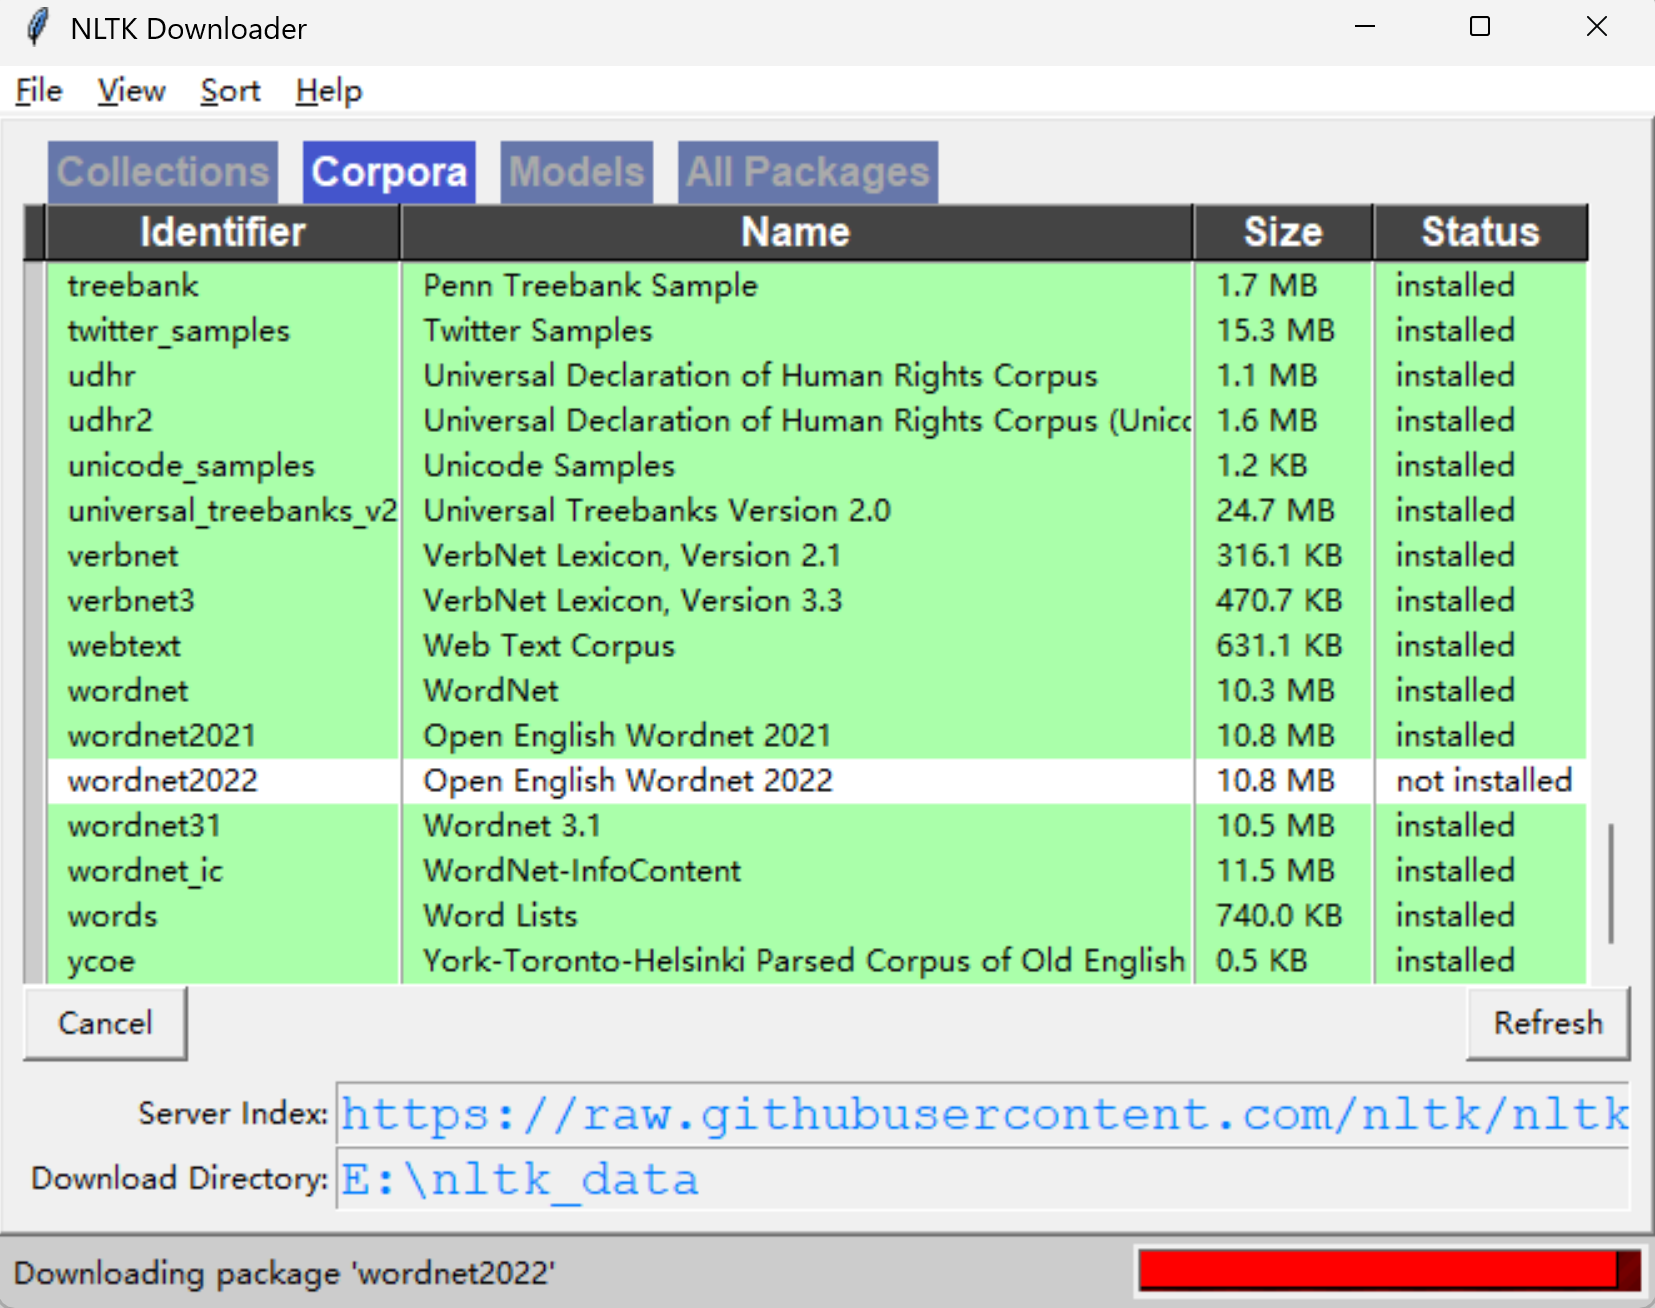

### (4) spaCy（工业级）

- 需要安装spacy模块`pip install spacy`
    - 下载en_core_web_sm预训练统计模型
        - `spacy download en_core_web_sm`
        - 或者`python -m spacy download en_core_web_sm`

In [13]:
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load("en_core_web_sm")  # 需要先下载en_core_web_sm
doc = nlp("I love NLP! It's great.")
tokens = [token.text for token in doc]
print(tokens)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 2.3 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.7 MB/s eta 0:00:05
     ------- -------------------------------- 2.4/12.8 MB 3.4 MB/s eta 0:00:04
     --------- ------------------------------ 2.9/12.8 MB 3.5 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 4.1 MB/s eta 0:00:03
     ------------------ --------------------- 5.8/12.8 MB 4.5 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 4.6 MB/s eta 0:00:02
     --------------------------- ------------ 8.7/12.8 MB 5.4 MB/s eta 0:00:01
  

- 代码说明：
    - en_core_web_sm 是spaCy库中针对英文的一个预训练统计模型和语言管道包。

----

- 下面三个分词算法是这是现代NLP（如BERT、GPT）中真正重要的分词算法，解决传统分词的两个问题：
    - 词袋中未登录词（如"covfefe"）
    - 词形态变化（如"playing"、"played"与"play"的关系）

- 使用transformers框架的AuoTokenizer或者Tokenizer来使用分词。
    - 安装transformers框架：`pip install transformers`
- 也可以使用HuggingFace提供的Tokenizer分词框架来使用分词。
    - 安装Tokenizers框架：`pip install tokenizers`
    - Tokenizers 提供了当今最常用分词器的实现，专注于高性能和高通用性。这些分词器也应用于Transformers。

```mermaid
graph TD
    A([开始]) --> B(分词)
    B --> C{算法类型}
    C -->|BPE| D(合并频繁出现的字符对)
    C -->|WordPiece| E(在词汇量范围内<br>合并字符对)
    C -->|SentencePiece| F(使用 Unigram 模型编码单词)
    D --> G(重复直至满足停止条件)
    E --> G
    F --> G
    G --> H([最终子词单元])
```

### (5) BPE（Byte Pair Encoding，字节对编码）

- BPE说明：
    - 原理：从字符级别开始，迭代合并最高频的字符对
    - 使用模型：GPT、GPT-2、RoBERTa
        - `https://huggingface.co/openai-community/openai-gpt`
        - `https://huggingface.co/openai-community/gpt2`
        - `https://huggingface.co/FacebookAI/roberta-base`

In [11]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/gpt2/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line, add_special_tokens=False).tokens
print(tokens)

['Hello', '!', 'ĠHow', 'Ġare', 'Ġyou', '?', 'ĠI', "'m", 'Ġfine', ',', 'Ġthank', 'Ġyou']


- 代码说明：
    - `Ġ`是 GPT-2、RoBERTa 等模型的分词器中用来代表原始空格的特殊标记。因为这些模型的分词器在预处理时，会把空格编码成一个可见的符号。这样做的好处是让模型能够区分“单词开头的空格”和“单词内部的子词”。
        - `Ġ`字符（拉丁大写字母 G 带有短音符）的 Unicode 码点是 U+0120.

In [12]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("./models/gpt2")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.tokenize(line)
print(tokens)

['Hello', '!', 'ĠHow', 'Ġare', 'Ġyou', '?', 'ĠI', "'m", 'Ġfine', ',', 'Ġthank', 'Ġyou']


In [25]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/openai-gpt/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['hello</w>', '!</w>', 'how</w>', 'are</w>', 'you</w>', '?</w>', 'i</w>', "'</w>", 'm</w>', 'fine</w>', ',</w>', 'thank</w>', 'you</w>']


In [24]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/roberta-base/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['<s>', 'Hello', '!', 'ĠHow', 'Ġare', 'Ġyou', '?', 'ĠI', "'m", 'Ġfine', ',', 'Ġthank', 'Ġyou', '</s>']


### (6) WordPiece

- WordPiece说明
    - 原理：类似BPE，但合并时选择最大化语言模型似然度的子词
    - 使用模型：BERT、DistilBERT
        - 中文：`https://huggingface.co/google-bert/bert-base-chinese`
        - 多语言：`https://huggingface.co/google-bert/bert-base-multilingual-cased`
        - 英文：`https://huggingface.co/google-bert/bert-large-uncased`
        - `https://huggingface.co/distilbert/distilbert-base-uncased`

In [23]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/bert-large-uncased/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['[CLS]', 'hello', '!', 'how', 'are', 'you', '?', 'i', "'", 'm', 'fine', ',', 'thank', 'you', '[SEP]']


In [22]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/bert-base-chinese/tokenizer.json")
line = "原理：类似BPE，但合并时选择最大化语言模型似然度的子词"
tokens = tokenizer.encode(line).tokens
print(tokens)

['[CLS]', '原', '理', '：', '类', '似', '[UNK]', '，', '但', '合', '并', '时', '选', '择', '最', '大', '化', '语', '言', '模', '型', '似', '然', '度', '的', '子', '词', '[SEP]']


In [21]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/distilbert-base-uncased/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['[CLS]', 'hello', '!', 'how', 'are', 'you', '?', 'i', "'", 'm', 'fine', ',', 'thank', 'you', '[SEP]']


### (7) SentencePiece

- SentencePiece说明：
    - 原理：基于语言模型概率，直接对句子进行子词切分。
    - 特点：可以直接处理原始文本（包括空格），无需预分词。
    - 使用模型：ALBERT、T5、XLNet。
        - `https://huggingface.co/google-t5/t5-base`
        - `https://huggingface.co/albert/albert-base-v2`
        - `https://huggingface.co/xlnet/xlnet-large-cased`

In [27]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/t5-base/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['▁Hello', '!', '▁How', '▁are', '▁you', '?', '▁I', "'", 'm', '▁fine', ',', '▁thank', '▁you', '</s>']


In [28]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/albert-base-v2/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['[CLS]', '▁hello', '!', '▁how', '▁are', '▁you', '?', '▁i', "'", 'm', '▁fine', ',', '▁thank', '▁you', '[SEP]']


In [29]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/xlnet-large-cased/tokenizer.json")
line = "Hello! How are you? I'm fine, thank you"
tokens = tokenizer.encode(line).tokens
print(tokens)

['▁', 'Hello', '!', '▁How', '▁are', '▁you', '?', '▁I', "'", 'm', '▁fine', ',', '▁thank', '▁you', '<sep>', '<cls>']


## 1.2. 中文分词 

- 经典的中文分词技术：

| 类别 | 代表方法 | 核心原理 | 优点 | 缺点 |
| :--- | :--- | :--- | :--- | :--- |
| **基于词典匹配** | 正向/逆向最大匹配法 (FMM/BMM) | 将文本与一个预置的“大词典”进行匹配，依据特定方向找出最长的词。 | 简单、快速，易于实现。 | 对**未登录词**（不在词典中的新词、专有名词）束手无策，**歧义**处理能力差。 |
| **基于统计学习** | 隐马尔可夫模型 (HMM)、条件随机场 (CRF) | 将分词看作“序列标注”问题。通过学习已分词语料，教会模型如何给每个字打标签（B-词首, E-词尾等），以此来识别新词边界。 | 具有较好的**新词发现**能力，能处理一定的**歧义**。 | 需要大规模、高质量的已分词语料进行训练，对词典依赖较小。 |
| **基于深度学习** | BiLSTM-CRF、BERT微调 | 利用深度神经网络（如循环神经网络、Transformer）自动从海量数据中学习更复杂的上下文特征，超越人工设计的局限。 | **准确率顶尖**，对复杂歧义和上下文理解能力最强。 | 需要大量计算资源和数据，模型训练和推理速度较慢。 |

- 分词工具

| 工具名称 | 开发者/典型用户 | 主要特点 | 适用人群/场景 |
| :--- | :--- | :--- | :--- |
| **Jieba** | 社区开源 | **社区最流行**，轻量级，易上手，支持多种分词模式和自定义词典。 | **Python初学者**、快速原型开发、对精度要求不苛刻的通用任务。 |
| **HanLP** | 社区开源 | 功能强大，支持多语言（Python, Java等），提供多种算法模型，工业级应用。 | 需要丰富功能（如句法分析）、追求更高精度的**生产环境**或研究者。 |
| **LAC** | 百度 | 轻量级，**速度快**，同时提供词性、实体识别等功能，易集成。 | 对**分析速度**要求高、需要集成到大规模服务中的开发者。 |
| **THULAC** | 清华大学 | 准确率高，分词速度比Jieba更快 | **学术界**或**对准确率有较高要求**的中型项目。 |

- HanLP需要注册与API-Key，这里不介绍。
- LAC需要编译安装，这里不介绍。

### (1) 中文自然分词

In [30]:
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
tokens = list(line.strip().replace(" ", ""))   # strip去掉前后两边空格，使用replace把中间的空格替换掉
print(tokens)

['与', '英', '文', '天', '然', '的', '“', '空', '格', '分', '词', '”', '不', '同', '，', '中', '文', '分', '词', '（', 'C', 'h', 'i', 'n', 'e', 's', 'e', 'W', 'o', 'r', 'd', 'S', 'e', 'g', 'm', 'e', 'n', 't', 'a', 't', 'i', 'o', 'n', '）', '是', '将', '连', '续', '的', '汉', '字', '序', '列', '切', '分', '成', '有', '意', '义', '的', '独', '立', '词', '语', '的', '过', '程']


### (2) jieba分词

- 需要安装jeiba框架`pip install jieba`

In [34]:
import jieba
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
tokens = jieba.lcut(line)   # cut返回生成器，lcut返回列表。
print(tokens)

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\ThinkPad\AppData\Local\Temp\jieba.cache
Loading model cost 0.446 seconds.
Prefix dict has been built successfully.


['与', '英文', '天然', '的', '“', '空格', '分词', '”', '不同', '，', '中文', '分词', '（', 'Chinese', ' ', 'Word', ' ', 'Segmentation', '）', '是', '将', '连续', '的', '汉字', '序列', '切', '分成', '有', '意义', '的', '独立', '词语', '的', '过程']


- 代码说明：
    - jieba采用的词典，在其安装目录下：dict.txt。

### (3) THULAC分词

- 需要安装THULAC框架`pip install THULAC`

In [36]:
import thulac
# seg_only=True 表示只分词，不进行词性标注。初始化，默认模式：同时进行分词和词性标注
thu = thulac.thulac(seg_only=True)
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
result = thu.cut(line, text=True)
print(result)
# 输出示例：我/r 爱/v 北京/ns 天安门/ns

Model loaded succeed
与 英文 天然 的 “ 空格 分词 ” 不 同 ， 中文 分词 （ Chinese Word Segment ation ） 是 将 连 续 的 汉字 序列切 分成 有 意义 的 独立 词语 的 过程


- 代码说明：
    - 采用分词技术会出现一个问题：OOV（Out-Of-Vocabulary，未登录词）。一般建议按照汉字分词，也是目前常用的分词方式。

### (4) spacy中文分词

In [38]:
!python -m spacy download zh_core_web_sm
import spacy
nlp = spacy.load("zh_core_web_sm")  # 需要先下载en_core_web_sm
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
doc = nlp(line)
tokens = [token.text for token in doc]
print(tokens)

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/48.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/48.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/48.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/48.5 MB ? eta -:--:--
     ---------------------------------------- 0.5/48.5 MB 1.8 MB/s eta 0:00:28
     - -------------------------------------- 1.6/48.5 MB 3.3 MB/s eta 0:00:15
     -- ------------------------------------- 3.1/48.5 MB 5.0 MB/s eta 0:00:10
     --- ------------------------------------ 4.5/48.5 MB 5.2 MB/s eta 0:00:09
     ----- ---------------------------------- 6.8/48.5 MB 6.4 MB/s eta 0:00:07
     ------- -------------------------------- 9.2/48.5 MB 7.2 MB/s eta 0:00:06
     --------- ------------------------------ 11.8/48.5 MB 7.9 MB/s eta 0:00:05
     ----------- ---------------------------- 14.2/48.5 MB 8.3 MB/s eta 0:00:05


### (5) 深度学习分词

In [40]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("./models/bert-base-chinese/tokenizer.json")
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
tokens = tokenizer.encode(line).tokens
print(tokens)

['[CLS]', '与', '英', '文', '天', '然', '的', '[UNK]', '空', '格', '分', '词', '[UNK]', '不', '同', '，', '中', '文', '分', '词', '（', '[UNK]', '[UNK]', '[UNK]', '）', '是', '将', '连', '续', '的', '汉', '字', '序', '列', '切', '分', '成', '有', '意', '义', '的', '独', '立', '词', '语', '的', '过', '程', '[SEP]']


### (6) 正则表达式分词

In [43]:
regex = r"(?:[a-zA-Z]+(?:[-'][a-zA-Z]+)*)|(?:[a-zA-Z]*\d+(?:\.\d+)?[a-zA-Z]*)|(?:[\u4e00-\u9fff\u3400-\u4dbf])|(?:[^\u4e00-\u9fff\u3400-\u4dbf\w])|(?:\d+(?:\.\d+)?)"
# regex = r"(?:[a-zA-Z]+(?:[-'][a-zA-Z]+)*)|(?:[a-zA-Z]*\d+(?:\.\d+)?[a-zA-Z]*)|(?:[\u4e00-\u9fff\u3400-\u4dbf]+)|(?:[^\u4e00-\u9fff\u3400-\u4dbf\w])|(?:\d+(?:\.\d+)?)"
import re
line = "与英文天然的“空格分词”不同，中文分词（Chinese Word Segmentation）是将连续的汉字序列切分成有意义的独立词语的过程"
tokens = re.findall(regex, line)
print(tokens)

['与', '英', '文', '天', '然', '的', '“', '空', '格', '分', '词', '”', '不', '同', '，', '中', '文', '分', '词', '（', 'Chinese', ' ', 'Word', ' ', 'Segmentation', '）', '是', '将', '连', '续', '的', '汉', '字', '序', '列', '切', '分', '成', '有', '意', '义', '的', '独', '立', '词', '语', '的', '过', '程']


## 1.3. 分词算法

- 中文分词效果好不好对信息检索、实验结果还是有很大影响的，中文分词与英文分词有很大的不同，对英文而言，一个单词就是一个词，而汉语是以字为基本的书写单位，词语之间没有明显的区分标记，需要人为切分。
- 更加复杂的情况是中英文混合的分词情况，分词处理的算法更加负责。
- 不管算法多么复杂，总体讲分成4大类算法，我们分别对集中算法进行介绍
    - **基于规则（词典）的分词方法**
    - **基于统计的分词方法**
    - **基于语义的分词方法**
    - **基于语义的分词方法**

### (1) 规则分词法

- 规则分词法就是讲需要分词的文本与一个已知的词典进行机械匹配，所以该方法也称机械分词法。使用不同的分词文本与字典的匹配方式，我们可以把规则分词法，细分为具体的不同算法：
    - 最大匹配法（MM）
    - 逆向最大匹配法（RMM）
    - 逐词遍历法
    - 设立切分标志法
    - 最佳匹配法（OM） 

- **最大匹配法（MM）**
    1. 步骤1：先获取词典中词条的最大长度，假设为$N$。
    2. 步骤2：在当前分词文本位置取出$N$长的字符串$W$，把$W$与词典匹配。
        - 匹配成功，则这个$N$长的字符串就是一个词，把文本位置下移一个，继续步骤2。
        - 匹配失败，则把$N$长字符串去掉最后一个字，继续匹配，以此类推，直到$N$长字符串处理完毕。
    - 步骤3：直到处理到文本末尾，所有文本都处理完毕。

- **逆向最大匹配法（RMM）**
    1. 步骤1：先获取词典中词条的最大长度，假设为$N$。
    2. 步骤2：在当前分词文本位置取出$N$长的字符串$W$，把$W$与词典匹配。
        - 匹配成功，则这个$N$长的字符串就是一个词，把文本位置下移一个，继续步骤2。
        - 匹配失败，则把$N$长字符串去掉第一个字，继续匹配，以此类推，直到$N$长字符串处理完毕。
    - 步骤3：直到处理到文本末尾，所有文本都处理完毕。
    - 说明：
        - RMM与MM算法本质一样，只是舍弃的字的方向不同，MM从后舍弃，RMM从前舍弃。
        - 从事情效果来说，RMM的匹配准确率要高于MM的匹配准确率。

- **逐词遍历法**
    1. 对词典中的词，按照从短到长排序。
    2. 按照词典中词的长度由长递减取词，并与被分词的文本逐一匹配。
    - 说明：
        - 这种分词法缺陷太多，效率太低，不建议使用。

- **设立切分标志法**
    1. 步骤1： 切分标记法先把文本分成不同的句子；
    2. 步骤2：对切分的句子再使用MM或者RMM分词法分词。
    - 说明：
        - 该分词法，先使用标点符号等切分标志，把分词文本切分成多个句子。句子的切分根据切分方式，分成自然切分与非自然切分。
            - 自然切分：利用正常语言的标点符号切分。
            - 非自然切分：利用一些一些特殊或者约定的字作为分句，比如："的"这样副词等。

- **最佳匹配法（OM）**
    - 最佳匹配法实际是对词典的词按照长度排序，匹配的时候不是全词典匹配，而是在字典长度的子词典中匹配。提升匹配的效率。
    - 对词典按照长度分组的方式可以采用不同的数据结构实现。

- **规则分词法实现**
    - 采用MM算法，MM算法实现的步骤：
        1. 加载词典（我们忽略词典中词频与词性）
        2. 对词典按照词的长度排序，并获取最长词的长度。
        3. 对分词文本使用自然方式进行分句处理；
        4. 循环对每个分句进行MM算法分词。

- 加载词典

In [44]:
dict_file = "dict.txt"
dictionary = {}
with open(dict_file, encoding="UTF-8") as f:
    lines = f.readlines()
    for line in lines:
        word, freq, tag = line.strip().split(" ")
        dictionary[word] = freq
# 注意：jieba提供的词典349046个词，其中"B超"重复。
# 注意：其中的词性，在这儿舍弃了。
print(len(dictionary))  # 数据太长，在jupyter中不适合输出。

349045


- 对词典排序，并获取最长词的长度

In [45]:
sorted_dict = {k: v for k, v in sorted(dictionary.items(), key=lambda x: len(x[0]), reverse=True)}

MAX_LEN = len(list(sorted_dict.items())[0][0])
print(list(sorted_dict.items())[0][0])
print(MAX_LEN)

侵华日军南京大屠杀遇难同胞纪念馆
16


- 对分词文本使用自然方式进行分句处理

In [46]:
import re
# 我们依然使用复旦大学的汉语语料库来作为验证数据集，使用一篇文章
corpus_file = "corpus/fudan/train/C3-Art/C3-Art0001.txt"

# 读取文件的文本，并且预处理
with open(corpus_file, encoding="GB18030") as f:
    lines = f.readlines()
    # 数据预处理
    text = "".join(lines)
    text = text.strip()
    # 去除非汉字符号
    # text = re.sub(r'[^\u4e00-\u9fa5]+', '', text)
    # 去除换行符
    text = re.sub(r'[\n\r＊]', '', text)

# 分句
pattern = r"[\n\r.!。！]" # 指定的分句符号，可以自己添加
sentences = re.split(pattern, text)
print(len(sentences))

45


- 循环对每个分句进行MM算法分词

In [47]:
words = []
for sen  in sentences:
    print(sen)
    # 开始对句进行分词
    tmp_sen = sen.strip() #去掉两端空格
    len_tmp = min(MAX_LEN, len(tmp_sen))
    while len_tmp >= 1:
        # 取匹配文本串
        word_tmp = tmp_sen[:len_tmp]
        # print(":", word_tmp)  # 恢复注释，进行调试
        # 匹配词典
        if word_tmp in dictionary.keys():
            # 匹配成功
            words.append(word_tmp)
            # print("\t|", word_tmp)   # 恢复注释，进行调试
            tmp_sen = tmp_sen[len_tmp:]
            len_tmp = min(MAX_LEN, len(tmp_sen))
        else:
            # 匹配失败
            if len_tmp == 1: # 特殊情况
                words.append(word_tmp)
                # print("\t<", word_tmp)  # 恢复注释，进行调试
                tmp_sen = tmp_sen[len_tmp:]
                len_tmp = min(MAX_LEN, len(tmp_sen))
            else:
                len_tmp -= 1
                
    break            
        
print(words)

【 文献号 】1-2340【原文出处】中国图书评论【原刊地名】沈阳【原刊期号】199510【原刊页号】61-62【分 类 号】Z1【分 类 名】出版工作、图书评介【 作  者 】杨小民【复印期号】199602【 标  题 】图书评论应当重视对书籍装帧艺术的评价【 正  文 】    图书评论是近代报刊业兴起后，在世界各国得到长足发展的一种新型评论体裁
['【', ' ', '文献号', ' ', '】', '1', '-', '2', '3', '4', '0', '【', '原文', '出处', '】', '中国', '图书', '评论', '【', '原', '刊', '地名', '】', '沈阳', '【', '原', '刊', '期', '号', '】', '1', '9', '9', '5', '1', '0', '【', '原', '刊', '页', '号', '】', '6', '1', '-', '6', '2', '【', '分', ' ', '类', ' ', '号', '】', 'Z', '1', '【', '分', ' ', '类', ' ', '名', '】', '出版', '工作', '、', '图书', '评介', '【', ' ', '作', ' ', ' ', '者', ' ', '】', '杨', '小民', '【', '复印', '期', '号', '】', '1', '9', '9', '6', '0', '2', '【', ' ', '标', ' ', ' ', '题', ' ', '】', '图书', '评论', '应当', '重视', '对', '书籍装帧', '艺术', '的', '评价', '【', ' ', '正', ' ', ' ', '文', ' ', '】', ' ', ' ', ' ', ' ', '图书', '评论', '是', '近代', '报刊', '业', '兴起', '后', '，', '在世', '界', '各国', '得到', '长足发展', '的', '一种', '新型', '评论', '体裁']


### (2) 统计分词法

- 统计分词法是依据统计原则，如果一个字符串出现的次数越多，就越有可能是一个词。使用字与字相邻出现的概率或频率来判别其是否是一个词。
- 对某个文本中相邻出现的各个字的组合的频度进行统计，计算它们之间的组合出现的信息。组合出现的信息体现了汉字之间结合关系的紧密程度。当紧密程度高于某一个阈值时，便可以认为此字组可能构成了一个词。
- 与前面使用词典的方法不同的是，该方法也称为无字典分词。

- 统计分词法的主要的统计模型有：
    - N元文法模型（N-Gram）
    - 隐马尔可夫模型（Hiden Markov Model，HMM）、
    - 最大熵模型（ME）
    - 条件随机场模型（Conditional Random Fields，CRF）。

- 在实际应用中，统计分词法一般是与基于词典的分词方法结合起来：
    - 既发挥匹配分词切分速度快、效率高的特点；
    - 又具有无词典分词对生词识别，并自动消除歧义的优点。

- N-Gram模型(N元文法模型)实现
    - 我们选择n-gram实现分词，结巴分词采用HMM分词。

- N-Gram是自然语言处理中常见一种基于统计的分词语言模型。
    - 下面解释N-Gram模型的词是指：**基于词典匹配的词，或者无法形成词的单字**
    - 其基本思想是将文本$S$里面的内容按照词为单位进行大小为$N$的滑动窗口操作，形成了长度是$N$的词片段序列（切分路径）。每一个词片段称为Gram。
    - 由于存在词的歧义情况，N-Gram的切分路径存在多种情况，通过计算每种路径出现的概率，使用最大概率原则来选择合适的切分路径，最懂得到分词结果。
    - N-Gram模型就是解决上面切分与切分歧义的问题的算法（其实N-Gram不仅仅用于分词）。
- 理解N-Gram的一些基本概念：
    - 基于词的路径的理解，以`我是南京市长江大桥`为例(假设江大桥存在于词典)，可以组成如下路径：
        - $W_1=$我/是/南京/市/长江/大桥
        - $W_2=$我/是/南京/市/长江大桥
        - $W_3=$我/是/南京市/长江/大桥
        - $W_4=$我/是/南京市/长江大桥
        - $W_5=$我/是/南京/市长/江/大桥
        - $W_6=$我/是/南京/市长/江大桥
        - $W_7=$我/是/南京市长/江/大桥
        - $W_8=$我/是/南京市长/江大桥
    - 其中`我，是，市，江`是单字或者在词典中无法匹配的单字，`南京，市长，长江，大桥，南京市，江大桥，南京市长，长江大桥`
    - 概率计算
        - 概率计算就是计算上面8个路径的概率，然后选择概率最大的路径作为分词结果。
    - 问题：
        - 因为上面的单字与词存在依赖关系，也就是上面的概率计算实际上会用到条件概率的知识。
        - 依赖关系会变得比较复杂，比如在$W_1$路径中：长江依赖市、南京、是、我。这种依赖度的复杂度与文本长短相关，文本越长，计算概率的复杂度越高。
        - 为了解决概率的计算问题，就提出了N-Gram模型。

- N-Gram模型是基于一种假设：
    - 假定文本中的每个词(比如第$i$个词：$w_i$)与前面$N-1$个词有关，与更前面的词无关。
    - 这种假设被称为$N-1$阶马尔可夫假设，其对应的模型就称为N-Gram模型。
- N-Gram的$N$可以取值$1,2,3,\dots$，形成多种N-Gram，一般 Bi-Gram (N=2) 和 Tri-Gram (N=3)就够用了：
    - 1-Gram：Uni-Gram
    - 2-Gram：Bi-Gram （也称为一阶马尔可夫链）
    - 3-Gram：Tri-Gram（也称为二阶马尔可夫链）
- 理解N-Gram模型（以上面$W_1$路径为例）
    - Uni-Gram模型：`我/是/南京/市/长江/大桥`中每个词都是独立的，与前面无关，这样计算概率就使用独立事件的概率计算方式-联合概率函数就可以计算。
    - Bi-Gram模型：`我/是/南京/市/长江/大桥`中`长江`只与`市`有关，与更前面的`南京`无关，这样计算概率就可以利用贝叶斯条件概率计算公式计算。
    - 其他模型以此类推。

- 我们可以把上面**N-Gram模型分词**使用数学表达方式如下：
    - 假设有一个文本$S$，$W$是$S$的路径随机变量，取值：$W_1,W_2,\dots,W_n$。
    - 对于分词，实际上就是计算条件概率$P(W)$, 并取概率最大的路径$W ^ \ast$作为分词：
        - $W^\ast = \underset{W_i}{\arg\max} P(W_i)$

- 概率计算
    - 我们以词典表为例，可以得到概率计算公式：
        - $p(word) = \dfrac{C(word)}{\sum\limits_i{C({word}_i)}}$

- N-GRAM模型的实现直接参考jieba源代码实现，更加商业化的代码参考jieba源代码：`https://github.com/fxsjy/jieba`

- 我们采用Uni-Gram，这样每个词出现的概率是独立事件，计算起来比较容易。jieba分词使用的也是Uni-Gram模型分词。

- 加载词典，为了便于查询，把词典的词进行细分。
    - 比如加载了`南京市`,则直接切分成：
        - `南京市`
        - `南京`
        - `南`
    - 如果细分的不是词（不在词典中），则频率设置为0；如果已经是词，则保持词典不变。

In [49]:
dict_path = "dict.txt"
wfreq = {}   # 字典树
total = 0
# 打开文件
with open(dict_path, encoding="utf-8") as f:
    count = 0
    # 读取文件
    lines = f.readlines()
    # 读取每行解析
    for line in lines:
        # 分割每行（默认空格）
        word, freq = line.split()[:2]
        freq = int(freq)
        wfreq[word] = freq
        # 把每个词细分成一列，便于前缀查询（比如：南京市长->南->南京->南京市），细分的词不在字典，则添加到字典树，并且词频为0。
        # 这种拆分等于扩大词典容量
        for idx in range(len(word)):
            wfrag = word[:idx + 1]
            if wfrag not in wfreq:
                wfreq[wfrag] = 0  # 细分后的词不存在，就添加到字典树，并且词频为0
        total += freq
        count += 1
        
print(F"加载词典数量: {count}") # 测试下词典的总词量。
print("细分后的总词量：", total) # 前缀细分后的总词量。用来作为近似概率的分母，分子就是词的词频


加载词典数量: 349046
细分后的总词量： 60101967


- 使用这种细分的字典，主要便于查询（比如单词检索），这种查询还有一种更加彪悍（性能更优）的数据结构Trie树。如下图：
    - 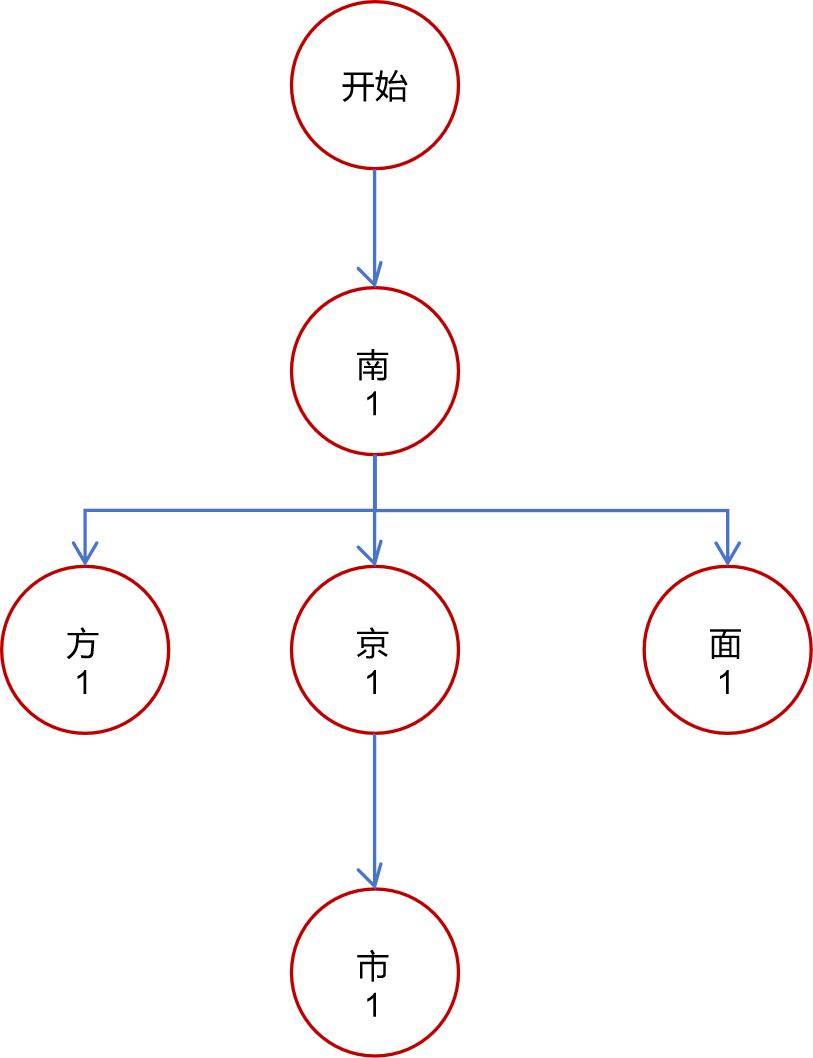
    - 使用字典比较直观（枚举方式），容易理解。在这里也能达到检索的目的（但是占用更多的空间）。

- 把需要分词的文本根据各种可能性切分为DAG（Directed Acyclic Graph：有向无环图）
    - 把文本切分，并在字典树查询，得到DAG：
        - DAG格式：`{start:[end1, end2, end3]}`
            - 比如：字符串`南京市长江大桥`，使用数字0,1,2,3表示每个字的下标，则`{0:[0,1,2]}`表示`南`,`南京`,`南京市`都是词，也就是南有三种组合成词方式。
    - 使用字典来实现树查询结构（DAG）是核心关键。

- DAG算法：以`南京市`长江大桥为列；
    - 1. 从`南`开始：
        - 1.1.判定`南`是否在词典；结果是`在`。
        - 1.2.继续判断`南京`是否在词典，结果是`在`。
        - 1.3.继续判断`南京市`是否在词典，结果`在`。
        - 1.4.继续判断`南京市长`是否在词典，结果是`不在`，把`南`的下标0，`京`的下标1，`市`的下标2形成列表，存放到字典：`{0:[0,1,2]}`
        - 1.5.对下一个字`京`开始,从1.1步骤继续重复处理。

In [50]:
sentence = "南京市长江大桥"
DAG = {}
N = len(sentence)
# 对句子细分
for k in range(N):
    tmplist = []
    i = k
    # 取句子中的字片段
    frag = sentence[k]
    while i < N and frag in wfreq:  # 前缀查询, 不在词典的就退出循环
        if wfreq[frag]:   # 词频不为0
            tmplist.append(i)
            print(frag, wfreq[frag],)   # 包含
        i += 1
        frag = sentence[k:i + 1] # 增加索引取片段
        print("\t|-",frag)
    if not tmplist:
        tmplist.append(k)
    DAG[k] = tmplist
print(DAG)

南 24296
	|- 南京
南京 7228
	|- 南京市
南京市 2046
	|- 南京市长
京 6583
	|- 京市
京市 2
	|- 京市长
市 40141
	|- 市长
市长 8782
	|- 市长江
长 40281
	|- 长江
长江 18930
	|- 长江大
	|- 长江大桥
长江大桥 3858
	|- 长江大桥
江 6083
	|- 江大
	|- 江大桥
大 144099
	|- 大桥
大桥 3288
	|- 大桥
桥 8499
	|- 桥
{0: [0, 1, 2], 1: [1, 2], 2: [2, 3], 3: [3, 4, 6], 4: [4], 5: [5, 6], 6: [6]}


- 理解DAG，只有理解DAG，我们就会形成直觉的最优路径求解算法。我们把上面结果表达成一个可视化有向无环图如下。
    - 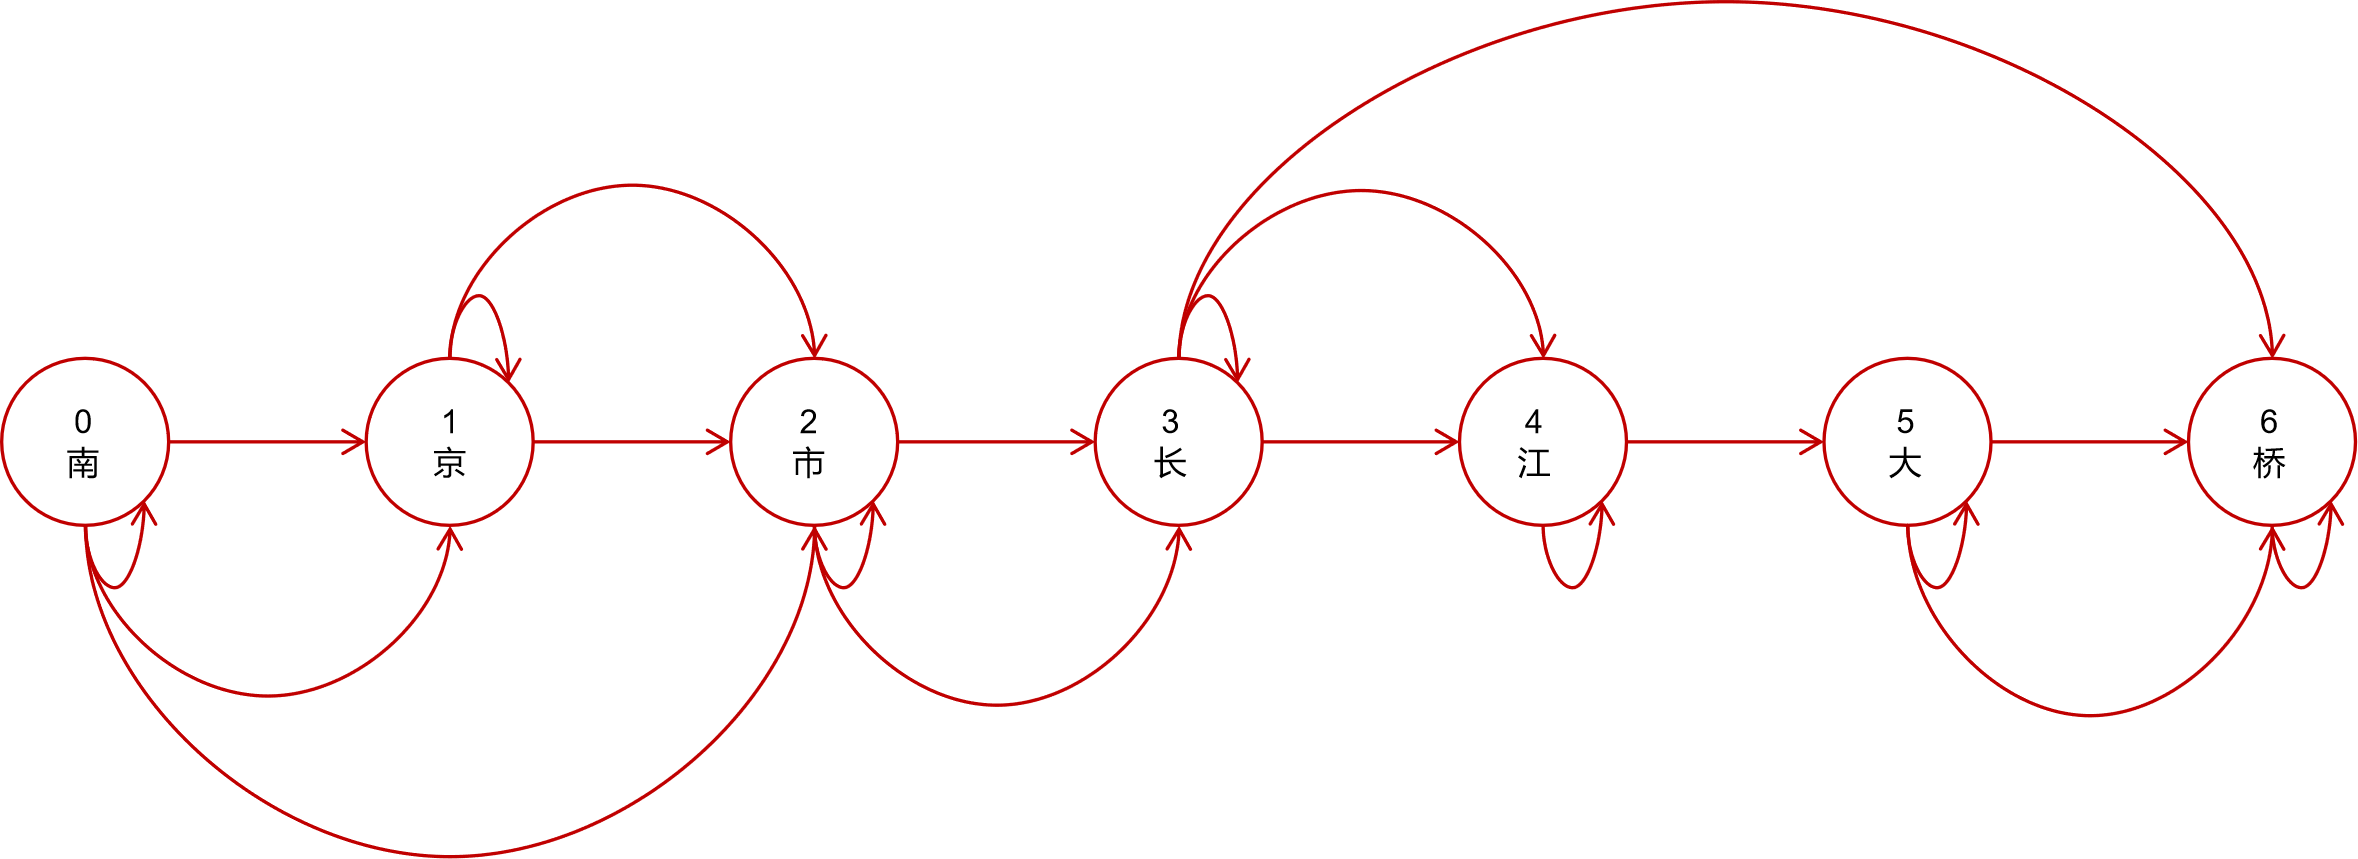

- 根据概率获取最优路径算法：
    - 动态规划求解：利用上面的字典树（字典树的理解就是上面的可视化图），找到一个概率最大的最优路径。
        - 把最优路径分解成子问题；
            - 假设`p(7)=1`
            - `6: [6]`: 的路径只有一个`桥`，概率${p(桥)}$，只有一个，肯定最大，得到最优$p(6)=p(桥)p(7)$。
            - `5: [5, 6]`的路径有两个`(大桥)(大，桥)`，根据1-Gram规则计算概率。      
                - $p(大,桥)=p(大) \ast p(桥)=p(大) \ast p(6)$    
                - $p(大桥)=p(大桥)p(7)$，$p(大桥)$的概率查询词典就可以得到。    
                - 选后选择最大概率：$p(5)=p(大桥)$   
            - `4: [4]`路径只有一个$江,大桥$，概率$p(江，大桥)=p(江)p(大桥)$，最优$p(4)=p(江)p(大桥)=p(江)p(5)$    
            - `3: [3, 4, 6]`：路径有三种`(长，江)(长江，大桥)（长江大桥）`，根据1-Gram规则计算概率：
                - $p(长，江)=p(长)p(江)=p(长)p(4)$
                - $p(长江，大桥)=p(长江)p(大桥)=p(长江)p(5)$
                - $p(长江大桥)=p(长江大桥)p(7)$
                - 选择最大$p(长江大桥)=p(3)$
            - `2: [2, 3]`的路径有两个`(市,长江大桥)(市长,江)`，根据1-Gram规则计算概率
                - $p(市,长江大桥)=p(市)p(长江大桥)=p(市)p(3)$
                - $p(市长,江)=p(市长)p(江)=p(市长)p(4)$
            - `1: [1, 2]`路径有两个`(京市，长江大桥)`（京，市）
                - $p(京市，长江大桥)=p(京市)p(长江大桥)=p(京市)p(3)$
                - $p(京，市)=p(京)p(市)=p(京)p(2)$
                - 选择最优$p(京，市)=p(1)$
            - `0: [0, 1, 2]`的路径有三个`(南，京)(南京，市)(南京市，长江大桥)`，根据1-Gram规则计算概率：
                - $p(南，京)=p(南)p(1)$
                - $p(南京，市)=p(南京)p(2)$
                - $p(南京市，长江大桥)=p(南京市)p(3)$
                
        - 选择子问题最优；
    - 因为词频太大，所以采用自然对数(对数是单调递增，不影响大小比较规律)，是防止数据溢出（溢出会产生自动切断）而产生计算错误。
    - 动态最优：

In [51]:
import math
route = {}
route[N] = (0, 0)
logtotal = math.log(total)
for idx in range(N - 1, -1, -1):
    # 把全局最优分解成局部最优的子问题。
    # 计算每个节点的概率（如果词典中的词不存在或者频次为0，则使用频次1代替），使用get的好处就是key不存在，返回0
    v = [(math.log(wfreq.get(sentence[idx:x + 1]) or 1) - logtotal + route[x + 1][0], x) for x in DAG[idx]]
    print(v)
    # 取节点最大概率节点
    route[idx] = max(v)
    # route[idx] = max((wfreq.get(sentence[idx:x + 1]) or 1 * route[x + 1][0] / logtotal, x) for x in DAG[idx])
print("------")
print(route)

[(-8.863849339256593, 6)]
[(-14.897146624673539, 5), (-9.813518371579148, 6)]
[(-19.011818225013663, 4)]
[(-26.319736180028066, 3), (-17.876568255130998, 4), (-9.653648934289546, 6)]
[(-16.96504852719957, 2), (-27.84291190164722, 3)]
[(-26.084355807486915, 1), (-26.87205488148482, 2)]
[(-33.89784192851655, 0), (-25.99088400324267, 1), (-19.941560115533193, 2)]
------
{7: (0, 0), 6: (-8.863849339256593, 6), 5: (-9.813518371579148, 6), 4: (-19.011818225013663, 4), 3: (-9.653648934289546, 6), 2: (-16.96504852719957, 2), 1: (-26.084355807486915, 1), 0: (-19.941560115533193, 2)}


- 利用最后路径实现最终的分词
    - 第一个字符开始，直接分词：
        - 0：得到2,第一个分词0-3
        - 3：得到6,第二个分析3-7
    - 如果是单字，则得到单字分词
    - 如果是单字，而且是英文或者数字，则直接放入缓冲；
    - 如果得到分词或者得到单字，则把缓冲转换为字符串作为分词。

In [52]:
import re
re_eng = re.compile('[a-zA-Z0-9]', re.U) # 切分连续的数字与英文字母
x = 0
buf = ''
lseg = []
while x < N:
    y = route[x][1] + 1
    print(x, y)
    l_word = sentence[x:y]
    if re_eng.match(l_word) and len(l_word) == 1: #不能匹配的单数字、字母，放入缓冲
        buf += l_word
        x = y
    else:
        if buf:
            lseg.append(buf+" ") # 新词出现，前面缓冲作为分词放入结果
            print("\t|-",buf)
            buf = ''
        lseg.append(l_word)
        x = y
# 不要遗漏最后的单字母与单数字构成的词。
if buf:
    lseg.append(buf + " ")

print(lseg)

0 3
3 7
['南京市', '长江大桥']


### (3) 语义分词法

- 语义分词法引入了语义分析，对自然语言自身的语言信息进行更多的处理。该方法主要体现在语义的如下几个方面：
    - 词性标注
    - 语义分析
    - 上下文分析

- **词性标注**
    - 词性标注是基于语义理解的分词方法的基础。通过对文本中的每个词进行词性标注，可以确定每个词在句子中的语法角色和语义含义。这样就可以根据词性标注结果来确定分词的边界，从而提高分词的准确性。

- **语义分析**
    - 语义分析是基于语义理解的分词方法的核心。通过对文本的语义进行分析，可以确定每个词在句子中的语义角色和语义含义。这样就可以根据语义分析结果来确定分词的边界，从而提高分词的准确性。

- **上下文分析**
    - 下文分析是基于语义理解的分词方法的重要组成部分。通过对文本中每个词的上下文进行分析，可以确定每个词在句子中的语义角色和语义含义。这样就可以根据上下文分析结果来确定分词的边界，从而提高分词的准确性。

### (4) 理解分词法

- 基于立即分词法主要是利用人工智能技术实现的分词法，这种方法能够处理一些复杂的语言现象，比如歧义、新词等。同时，它也能够处理一些特殊的语言现象，比如专有名词、缩写词等。但是，它需要大量的训练数据和计算资源。
- 基于理解分词法主要包含的技术：
    - 深度学习
    - 知识图谱

- **深度学习分词算法**
    - 基于深度学习的分词方法是指通过神经网络模型，对文本进行切分。

- **知识图谱分词算法**
    - 基于知识图谱的分词方法是指通过构建知识图谱，对文本进行切分。

-----

## 1.4. Tokenizer分词框架的使用

- 需要安装tokenizer：`pip install tokenizer`

- tokenizer处理文本的完整流程：

```mermaid
flowchart LR
    A[原始文本输入] --> B[Normalizer 标准化]
    B --> C[PreTokenizer 预分词]
    C --> D[Model 模型分词]
    D --> E[PostProcessor 后处理]
    E --> F[Encoding 输出]
```

### (1) 训练分词的实现

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

# 1. 初始化一个空的BPE模型
tokenizer = Tokenizer(models.BPE())

# 2. 设置预分词器和解码器（ByteLevel方式）
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer.decoder = decoders.ByteLevel()

# 3. 配置训练参数
trainer = trainers.BpeTrainer(
    vocab_size=30000,      # 词汇表大小
    min_frequency=2,       # token最小出现频率
    special_tokens=["<s>", "</s>", "<unk>", "<pad>"]
)

# 4. 准备训练文本文件列表或使用迭代器
files = ["/Volumes/AI/Datasets/train.zh"]
tokenizer.train(files, trainer)

# 5. 保存训练好的tokenizer
tokenizer.save("/Users/logicye/Code/ai_learning/notebooks/03_encoder_decoder/04_自然语言分词/datasets/my_tokenizer.json")


### (2) 使用分词

In [1]:
from tokenizers import Tokenizer
new_tokenizer = Tokenizer.from_file("/Users/logicye/Code/ai_learning/notebooks/03_encoder_decoder/04_自然语言分词/datasets/my_tokenizer.json")

# 对文本进行编码
text = " Word2Vec 的成功启发下，词嵌入技术不断演化，GloVe（Global Vectors for Word Representation）便是其中的杰出代表。GloVe 结合了全局词汇共现统计信息和局部上下文信息，在捕捉词汇语义方面表现出色。"
encoding = new_tokenizer.encode(text)

# 查看结果
print("Token IDs:", encoding.ids)
print("Tokens:", encoding.tokens)
print("Attention Mask:", encoding.attention_mask)

# 从token ID解码回文本
decoded_text = new_tokenizer.decode(encoding.ids)
print("Decoded:", decoded_text)

Token IDs: [11236, 10798, 21, 57, 6288, 6050, 1786, 15611, 339, 195, 1882, 26422, 1503, 2719, 23720, 195, 42, 33043, 57, 72, 641, 42, 79, 32400, 17539, 22828, 21311, 19166, 11236, 10798, 8932, 8709, 32125, 6046, 6992, 640, 11825, 10646, 18542, 2317, 188, 42, 33043, 57, 72, 37980, 207, 32224, 14581, 1116, 357, 5400, 33357, 16958, 10233, 719, 1676, 195, 222, 11948, 14581, 42794, 1543, 2043, 7443, 188]
Tokens: ['ĠW', 'ord', '2', 'V', 'ec', 'ĠçļĦ', 'æĪĲåĬŁ', 'åĲ¯åıĳ', 'ä¸ĭ', 'ï¼Į', 'è¯į', 'åµĮåħ¥', 'æĬĢæľ¯', 'ä¸įæĸŃ', 'æ¼ĶåĮĸ', 'ï¼Į', 'G', 'lo', 'V', 'e', 'ï¼Ī', 'G', 'l', 'obal', 'ĠV', 'ect', 'ors', 'Ġfor', 'ĠW', 'ord', 'ĠR', 'ep', 'res', 'ent', 'ation', 'ï¼ī', 'ä¾¿æĺ¯', 'åħ¶ä¸ŃçļĦ', 'æĿ°åĩº', 'ä»£è¡¨', 'ãĢĤ', 'G', 'lo', 'V', 'e', 'Ġç»ĵåĲĪ', 'äºĨ', 'åħ¨å±Ģ', 'è¯įæ±ĩ', 'åħ±', 'çİ°', 'ç»Łè®¡', 'ä¿¡æģ¯åĴĮ', 'å±Ģéĥ¨', 'ä¸Ĭä¸ĭ', 'æĸĩ', 'ä¿¡æģ¯', 'ï¼Į', 'åľ¨', 'æįķæįī', 'è¯įæ±ĩ', 'è¯Ńä¹ī', 'æĸ¹éĿ¢', 'è¡¨çİ°', 'åĩºèī²', 'ãĢĤ']
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### (3) 说明

- 一般我们都使用第三方预训练好的分词模型。